# Teste Interativo do `main.py`

Notebook de validação do pipeline completo. Executa todas as 7 etapas do projeto, uma de cada vez, permitindo inspecionar resultados intermediários.

**Etapas:**
1. EDA — gera o parquet processado (pulada se já existir)
2. Classificação supervisionada
3. Regressão supervisionada
4. Clusterização de aeroportos
5. Visualização geográfica
6. Detecção de anomalias
7. Análise de sazonalidade (recebe os anômalos da etapa 6)

> Para rodar o pipeline inteiro de uma vez, use `python main.py` no terminal.  
> Este notebook é útil pra debugar etapas específicas sem rerodar tudo.

In [1]:
import sys
from pathlib import Path

# Adiciona o diretório raiz do projeto ao PYTHONPATH
sys.path.append(str(Path(".").resolve().parent))

# Importa as funções do main
from main import (
    main,  
    run_eda,
    run_classification,
    run_regression,
    run_clustering,
    run_geomap,
    run_anomalies,
    run_seasonality,
)

In [2]:
# Roda o pipeline completo + gera o relatório HTML
main(show_plots=False, generate_html_report=True)

  PIPELINE COMPLETO — Tech Challenge: Atrasos de Voos nos EUA (2015)

ETAPA 1 — Análise Exploratória de Dados (EDA)
✓ Parquet processado já existe em data/processed/flights_model.parquet
  Rodando EDA em memória sem salvar (já temos o arquivo).
Carregando dados de: data/raw/flights.csv ...

=== Informações Básicas ===
Shape: (5819079, 31)

Head:
shape: (5, 31)
┌──────┬───────┬─────┬─────────────┬───┬──────────────┬──────────────┬──────────────┬──────────────┐
│ YEAR ┆ MONTH ┆ DAY ┆ DAY_OF_WEEK ┆ … ┆ SECURITY_DEL ┆ AIRLINE_DELA ┆ LATE_AIRCRAF ┆ WEATHER_DELA │
│ ---  ┆ ---   ┆ --- ┆ ---         ┆   ┆ AY           ┆ Y            ┆ T_DELAY      ┆ Y            │
│ i64  ┆ i64   ┆ i64 ┆ i64         ┆   ┆ ---          ┆ ---          ┆ ---          ┆ ---          │
│      ┆       ┆     ┆             ┆   ┆ i64          ┆ i64          ┆ i64          ┆ i64          │
╞══════╪═══════╪═════╪═════════════╪═══╪══════════════╪══════════════╪══════════════╪══════════════╡
│ 2015 ┆ 1     ┆ 1   ┆ 4       

## Etapa 1 — EDA

Gera o parquet processado em `data/processed/flights_model.parquet`.  
**Atenção:** essa etapa é pulada automaticamente se o parquet já existir.  
Pra forçar reprocessamento, delete o arquivo antes.

In [13]:
eda=run_eda(show_plots=True)


ETAPA 1 — Análise Exploratória de Dados (EDA)
✓ Parquet processado já existe em data/processed/flights_model.parquet
  Pulando EDA. Para forçar reprocessamento, delete o arquivo.


## Etapa 2 — Classificação supervisionada

Treina Logistic Regression e Random Forest pra prever se o voo vai atrasar (`is_delayed`).  
Retorna a instância do `FlightClassifier` pra você inspecionar métricas e pipelines.


ETAPA 2 — Modelagem Supervisionada: Classificação
Carregando dados de: data/processed/flights_model.parquet ...
Existe? True
Shape original: (5714008, 34)
Shape após seleção de features: (5714008, 11)
Amostragem aplicada (10%): (571400, 11)
X: (571400, 10) | y: (571400,)
Categóricas: ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'periodo_dia']
Numéricas: ['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'SCHEDULED_TIME', 'DISTANCE']
X_train: (457120, 10)
X_test:  (114280, 10)
y_train: (457120,)
y_test:  (114280,)

=== Treinando Logistic Regression ===

=== Treinando Random Forest ===

=== Comparação de modelos ===
             modelo  accuracy  precision   recall       f1  roc_auc
Logistic Regression  0.583409   0.447984 0.597044 0.511883 0.617667
      Random Forest  0.569330   0.436324 0.606874 0.507658 0.617527


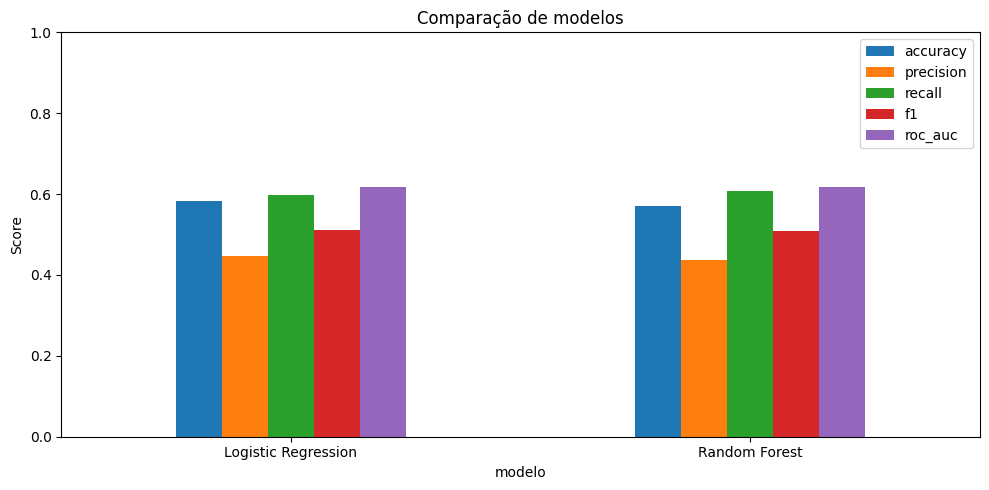

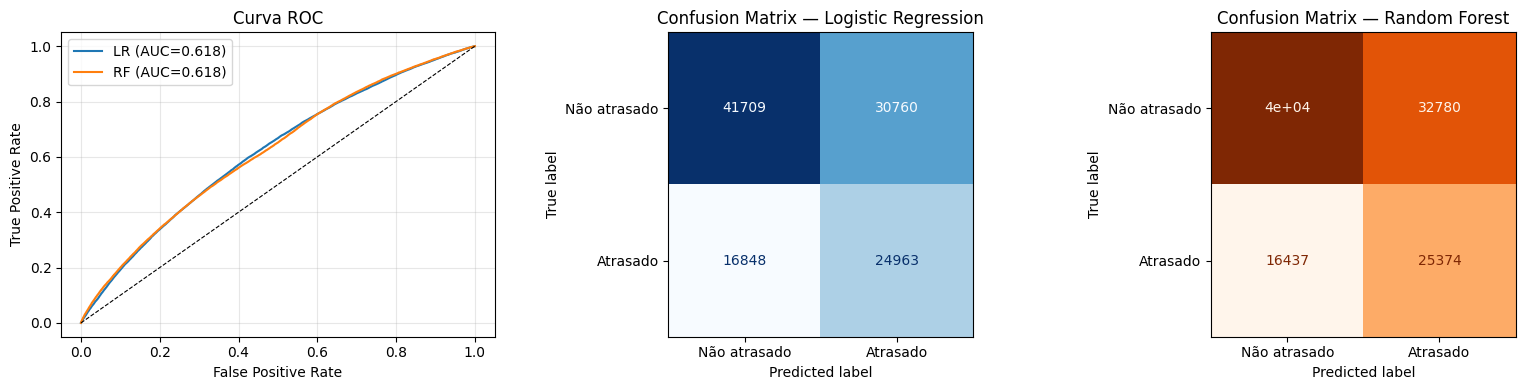

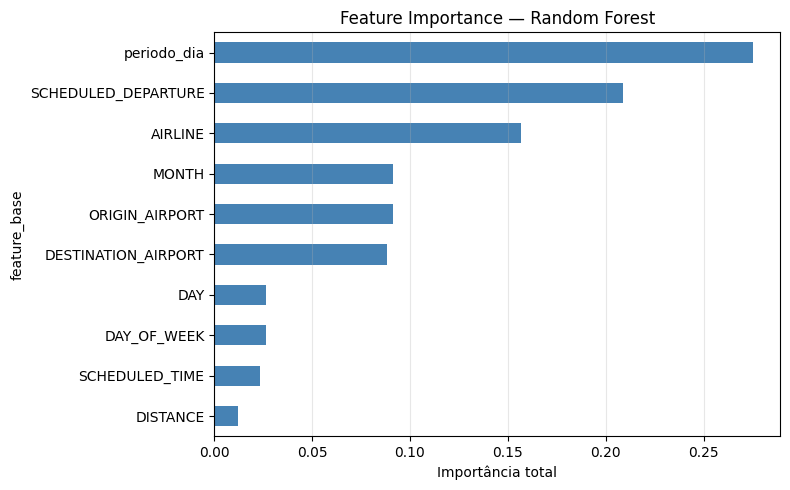

In [3]:
clf = run_classification(show_plots=True)

In [4]:
# Inspecionar a tabela comparativa
clf.comparison_df

,modelo,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.583409,0.447984,0.597044,0.511883,0.617667
1,Random Forest,0.569330,0.436324,0.606874,0.507658,0.617527


## Etapa 3 — Regressão supervisionada

Treina Linear Regression, Decision Tree e LightGBM pra prever quantos minutos de atraso (`ARRIVAL_DELAY`).


ETAPA 3 — Modelagem Supervisionada: Regressão
Carregando dados de: data/processed/flights_model.parquet ...
Existe? True
Shape original: (5714008, 34)
Shape após filtro e seleção: (5714008, 11)
Amostragem aplicada (30%): (1714202, 11)
X: (1714202, 10) | y: (1714202,)
Categóricas: ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'periodo_dia']
Numéricas: ['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'SCHEDULED_TIME', 'DISTANCE']
X_train: (1371361, 10)
X_test:  (342841, 10)
y_train: (1371361,)
y_test:  (342841,)
✓ Preprocessor cached — fit uma única vez

=== Treinando Linear Regression ===
⏱ Linear Regression treinou em 28.24s

=== Treinando Decision Tree ===
⏱ Decision Tree treinou em 19.32s

=== Treinando LightGBM ===
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011820 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 319

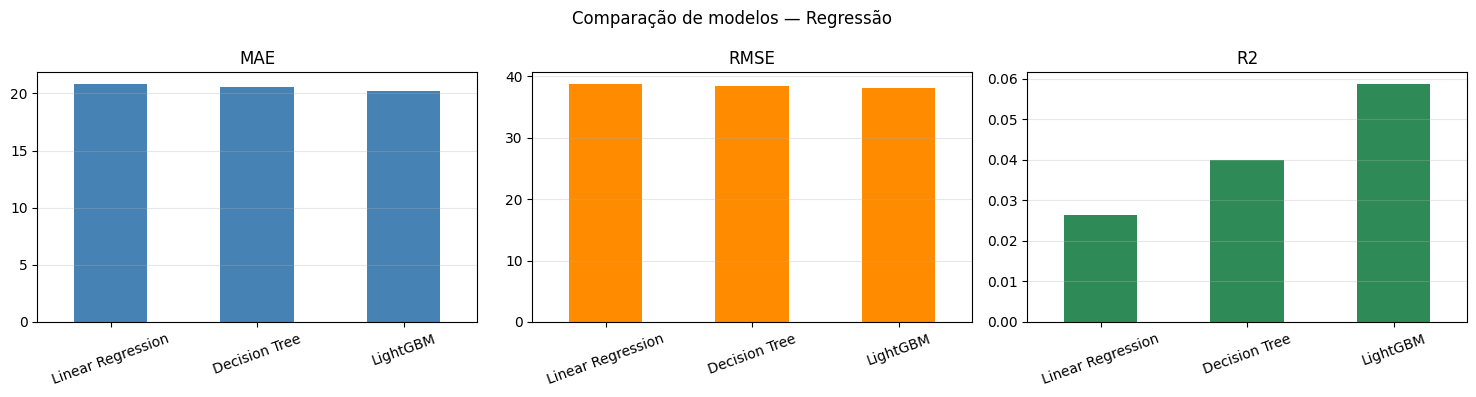

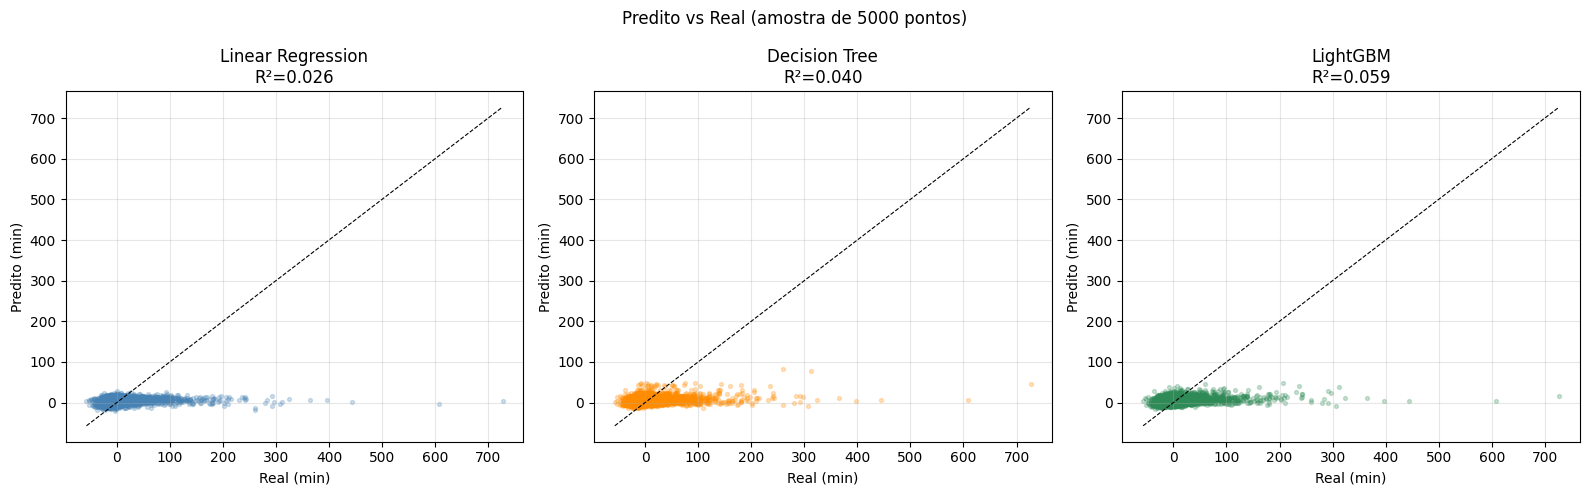

In [2]:
reg = run_regression(show_plots=True)

In [3]:
# Inspecionar tempos de treino e métricas
print(f"Linear Regression: {reg.lr_time:.2f}s")
print(f"Decision Tree:     {reg.dt_time:.2f}s")
print(f"LightGBM:          {reg.gb_time:.2f}s")
reg.comparison_df

Linear Regression: 28.24s
Decision Tree:     19.32s
LightGBM:          7.31s


,MAE,RMSE,R2
modelo,,,
Linear Regression,20.808534,38.699556,0.026390
Decision Tree,20.558215,38.429602,0.039926
LightGBM,20.239476,38.051818,0.058710


## Etapa 4 — Clusterização de aeroportos

KMeans agrupa os aeroportos por perfil operacional (taxa de atraso, volume, mix de horários, etc.).


ETAPA 4 — Modelagem Não Supervisionada: Clusterização
Carregando dados de: data/processed/flights_model.parquet ...
Existe? True
Shape: (5714008, 34)

=== Agregando features por aeroporto (mín. 500 voos) ===
Aeroportos com >= 500 voos: 403

=== Pré-processamento ===
Nulos por feature:
media_arrival_delay      0
mediana_arrival_delay    0
std_arrival_delay        0
taxa_atraso              0
taxa_atraso_grave        0
media_departure_delay    0
distancia_media          0
tempo_voo_medio          0
n_airlines               0
n_destinos               0
pct_manha                0
pct_tarde                0
pct_noite                0
dtype: int64

Shape para clusterização: (403, 13)

=== Buscando melhor k ===
k=2  inertia=4089.4  silhouette=0.2088
k=3  inertia=3336.4  silhouette=0.2193
k=4  inertia=3064.4  silhouette=0.1792
k=5  inertia=2913.9  silhouette=0.1815
k=6  inertia=2691.8  silhouette=0.1551
k=7  inertia=2571.0  silhouette=0.1585
k=8  inertia=2428.0  silhouette=0.1628
k=9  inertia

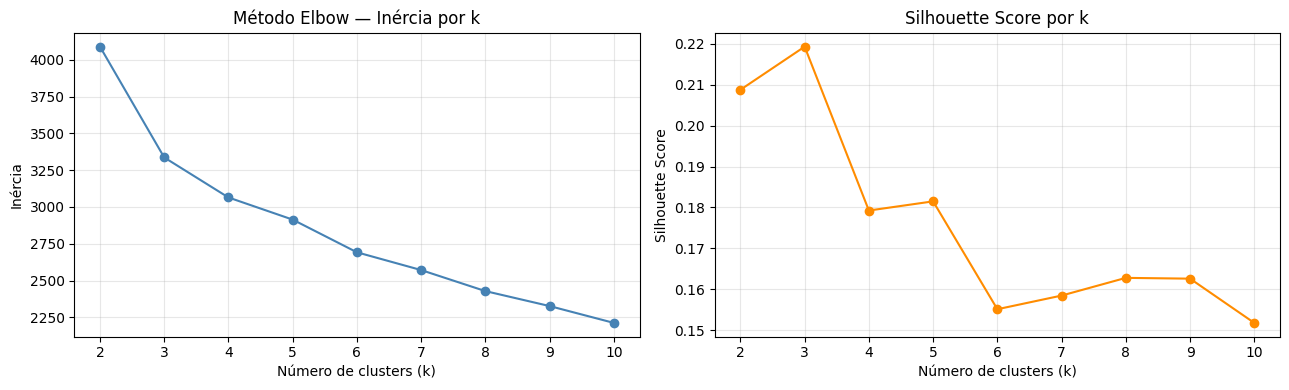


=== Treinando KMeans final com k=3 ===
Distribuição de aeroportos por cluster:
cluster
0    157
1    139
2    107
Name: count, dtype: int64

=== Perfil médio de cada cluster ===
         taxa_atraso  taxa_atraso_grave  media_arrival_delay  \
cluster                                                        
0               0.37               0.18                 6.49   
1               0.27               0.12                -0.42   
2               0.34               0.15                 2.32   

         media_departure_delay  std_arrival_delay  distancia_media  \
cluster                                                              
0                         8.12              46.22           413.76   
1                         3.50              37.48           487.07   
2                         7.39              36.39           914.54   

         n_destinos  qtd_voos  
cluster                        
0              5.83   3919.35  
1             10.17   2461.94  
2             53.52  

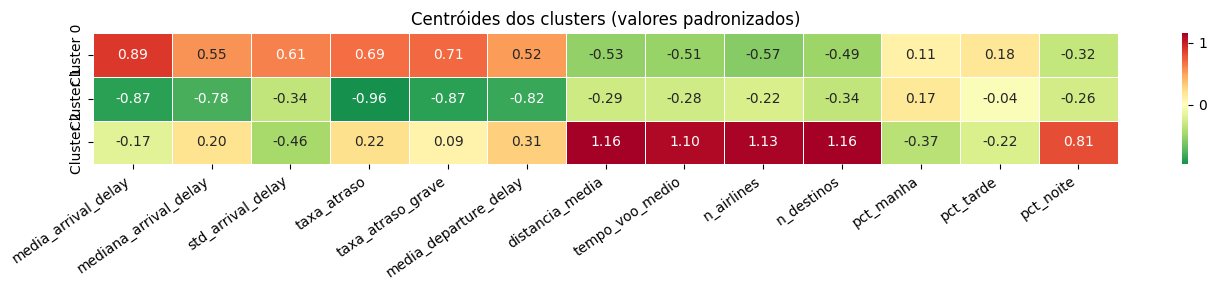

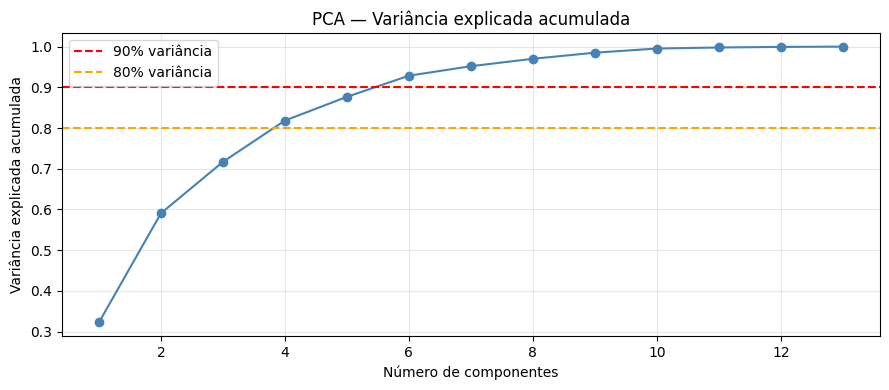

Componentes necessários para 90% da variância: 6
PC1 explica 32.3% | PC2 explica 26.8% | Total: 59.1%


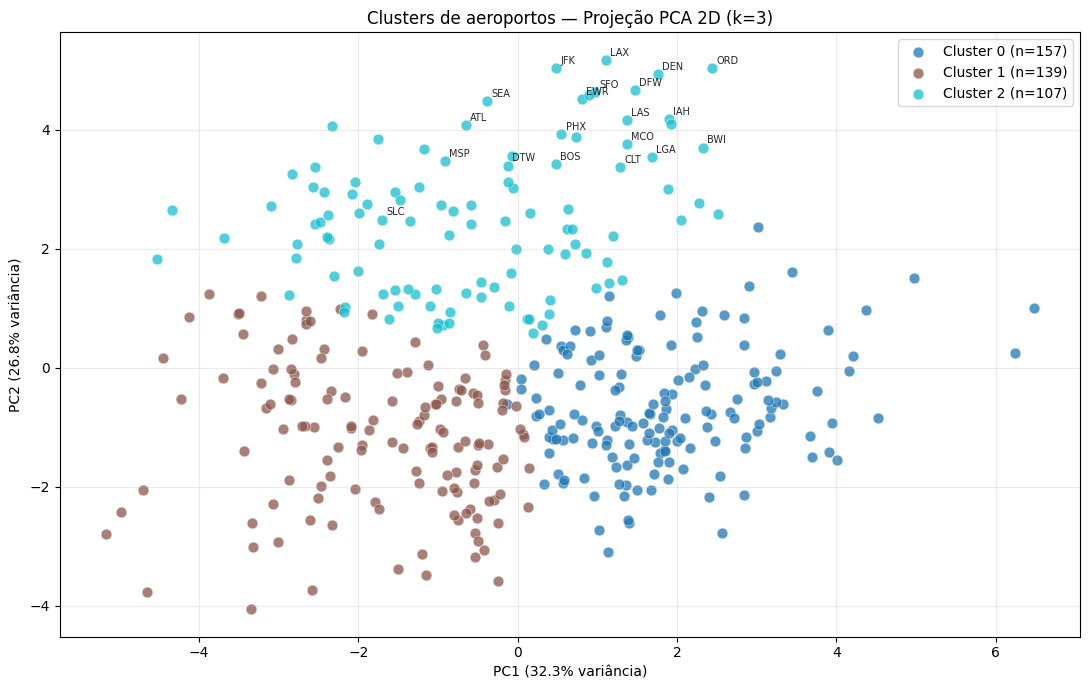

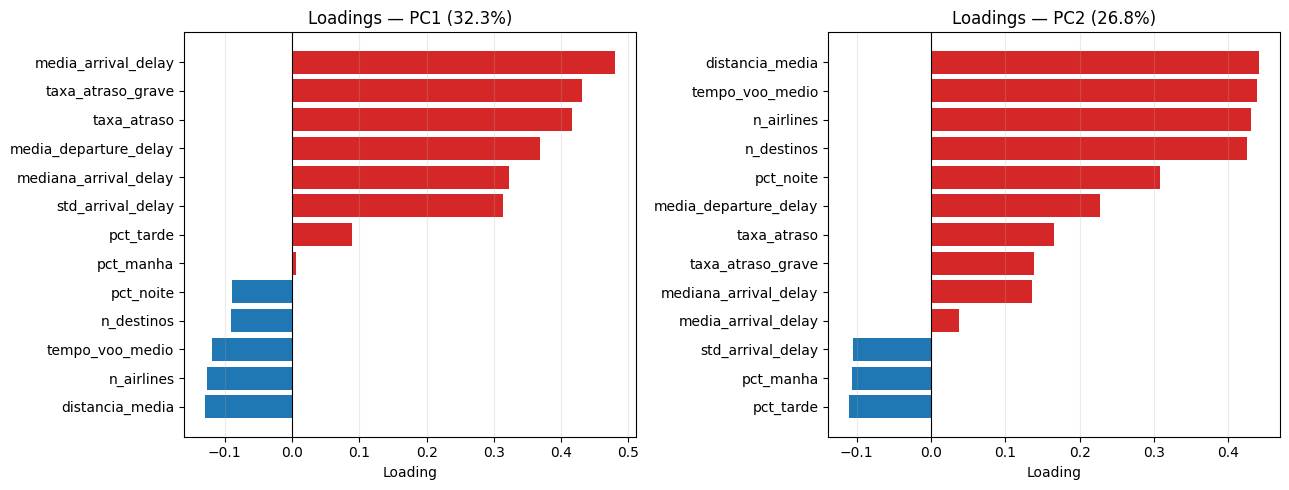

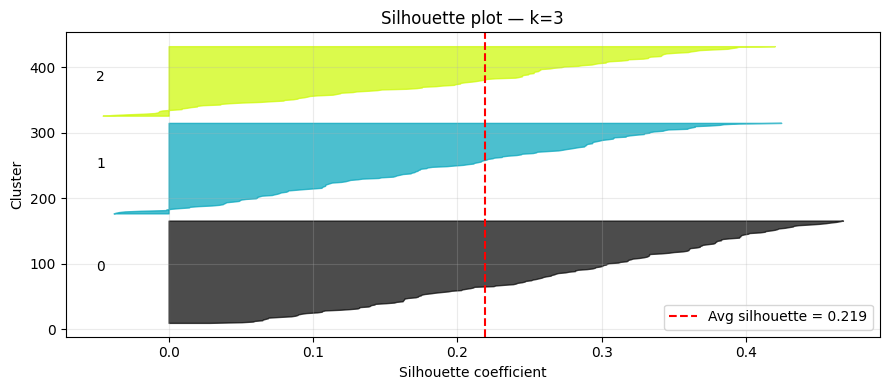

In [4]:
clusterer = run_clustering(show_plots=True)

In [5]:
# Inspecionar k escolhido e perfil dos clusters
print(f"k escolhido: {clusterer.k_final}")
clusterer.perfil

k escolhido: 3


,taxa_atraso,taxa_atraso_grave,media_arrival_delay,media_departure_delay,std_arrival_delay,distancia_media,n_destinos,qtd_voos
cluster,,,,,,,,
0,0.37,0.18,6.49,8.12,46.22,413.76,5.83,3919.35
1,0.27,0.12,-0.42,3.50,37.48,487.07,10.17,2461.94
2,0.34,0.15,2.32,7.39,36.39,914.54,53.52,44096.01


## Etapa 5 — Visualização geográfica

Gera 5 mapas: scatter geo por delay, scatter por cluster, linhas de rotas, heatmap Folium e choropleth por estado.

In [6]:
mapper = run_geomap(show_plots=True)


ETAPA 5 — Visualização Geográfica
Aeroportos com coordenadas: 181
Carregando dados de: data/processed/flights_model.parquet ...
Existe? True
Shape: (5714008, 34)
Aeroportos com coords: 176 de 403 no dataset
Modelo não encontrado — reclusterizando localmente...
✓ Reclusterizado com k=4
cluster
0    33
1    24
2    72
3    47
Name: count, dtype: int64
Rotas com coords completas: 139
Mapa salvo em mapa_atrasos_heatmap.html


In [ ]:
# Os figs ficam acessíveis individualmente — útil pra reexibir um específico
# mapper.fig_delay_rate.show()
# mapper.fig_clusters.show()
# mapper.fig_routes.show()
# mapper.fig_state_choropleth.show()
# mapper.folium_map

## Etapa 6 — Detecção de anomalias

Combina Isolation Forest, LOF e silhouette individual do KMeans pra identificar aeroportos atípicos.


ETAPA 6 — Detecção de Anomalias
Carregando dados de: data/processed/flights_model.parquet ...
Existe? True
Shape: (5714008, 34)

=== Agregando features por aeroporto (mín. 500 voos) ===
Aeroportos: 403
Shape: (403, 15)

=== Isolation Forest ===
Anomalias detectadas: 21 de 403

Top 10 mais anômalos:
                taxa_atraso  media_arrival_delay  std_arrival_delay  \
ORIGIN_AIRPORT                                                        
ASE                0.448667            15.492492          57.819063   
BPT                0.449724            16.154696          63.937161   
EGE                0.388147            12.401503          85.413183   
LWS                0.164966            -6.620748          21.075043   
YAK                0.244615            -5.632308          27.369613   
PSE                0.246612            -4.405149          32.482369   
CDV                0.314417            -1.607362          29.841298   
ORD                0.409616             8.600790          43

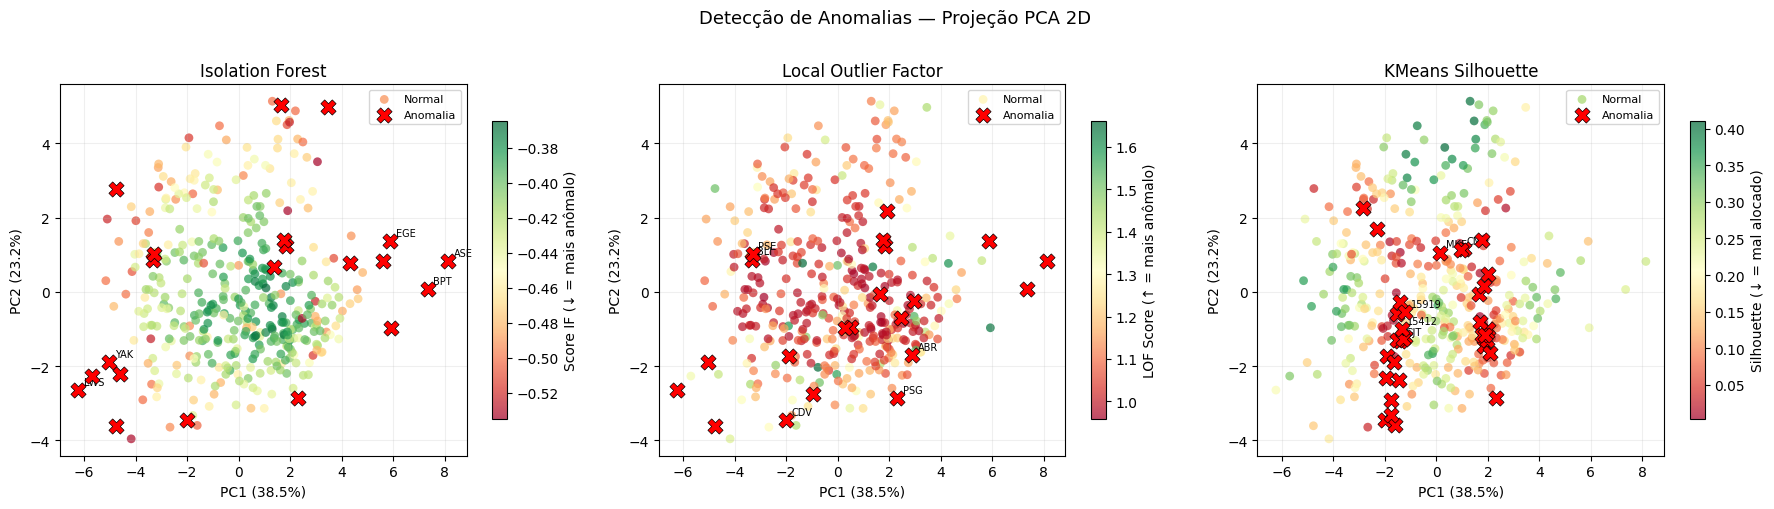

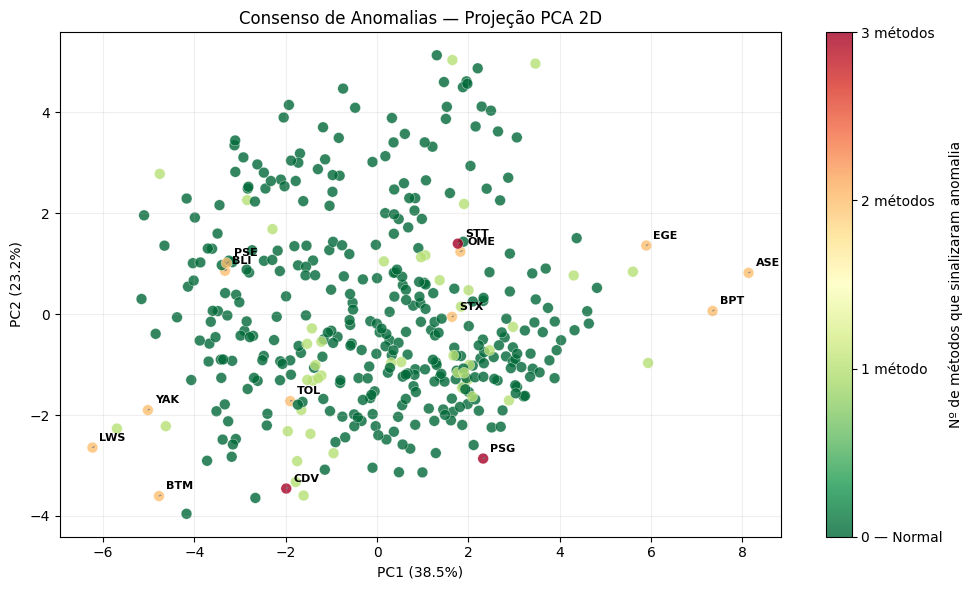

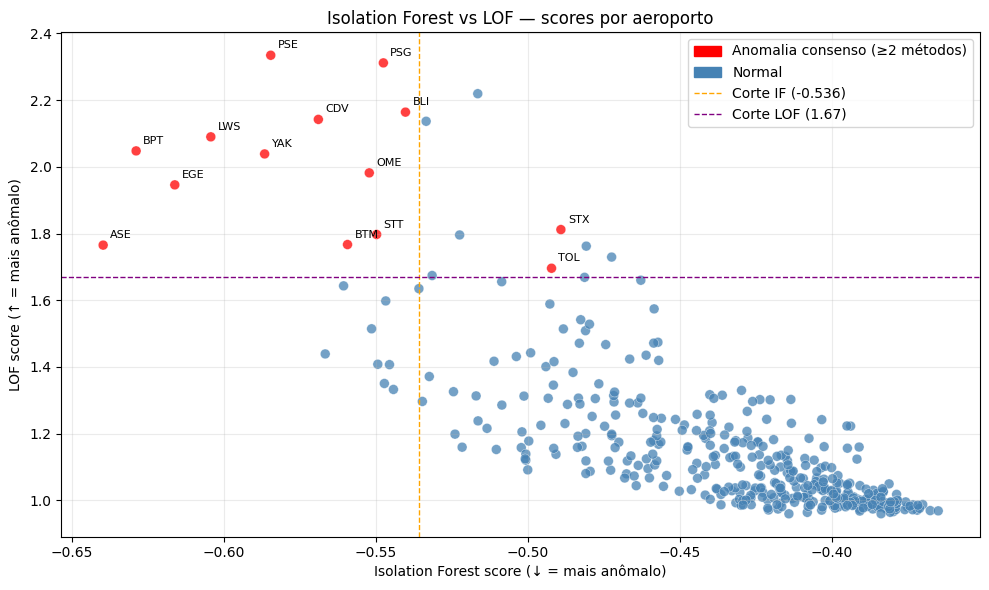

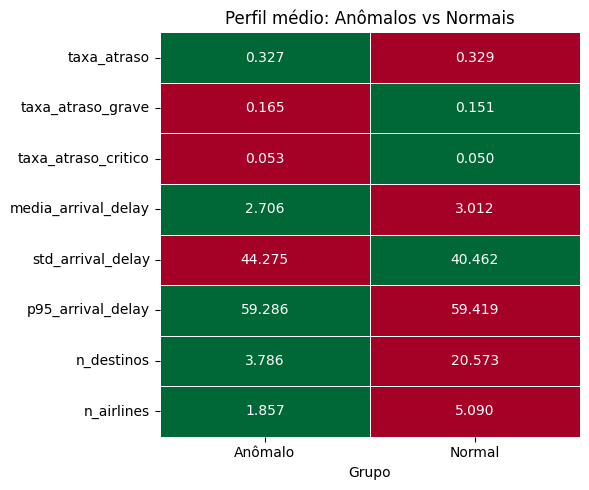

grupo                Anômalo  Normal
taxa_atraso            0.327   0.329
taxa_atraso_grave      0.165   0.151
taxa_atraso_critico    0.053   0.050
media_arrival_delay    2.706   3.012
std_arrival_delay     44.275  40.462
p95_arrival_delay     59.286  59.419
n_destinos             3.786  20.573
n_airlines             1.857   5.090


In [7]:
detector = run_anomalies(show_plots=True)

In [8]:
# Lista dos aeroportos anômalos identificados (vai ser usada na etapa 7)
anomalous_airports = detector.anomalos_consenso.index.tolist()
print(f"Anômalos detectados ({len(anomalous_airports)}):", anomalous_airports)

Anômalos detectados (14): ['TOL', 'YAK', 'BLI', 'CDV', 'BTM', 'STX', 'LWS', 'OME', 'EGE', 'PSG', 'STT', 'ASE', 'BPT', 'PSE']


## Etapa 7 — Análise de sazonalidade

Identifica padrões temporais (mês, dia da semana, período do dia) e cruza com os aeroportos anômalos da etapa 6.


ETAPA 7 — Análise de Sazonalidade
Carregando dados de: data/processed/flights_model.parquet ...
Existe? True
Voos: 5,714,008
Meses presentes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


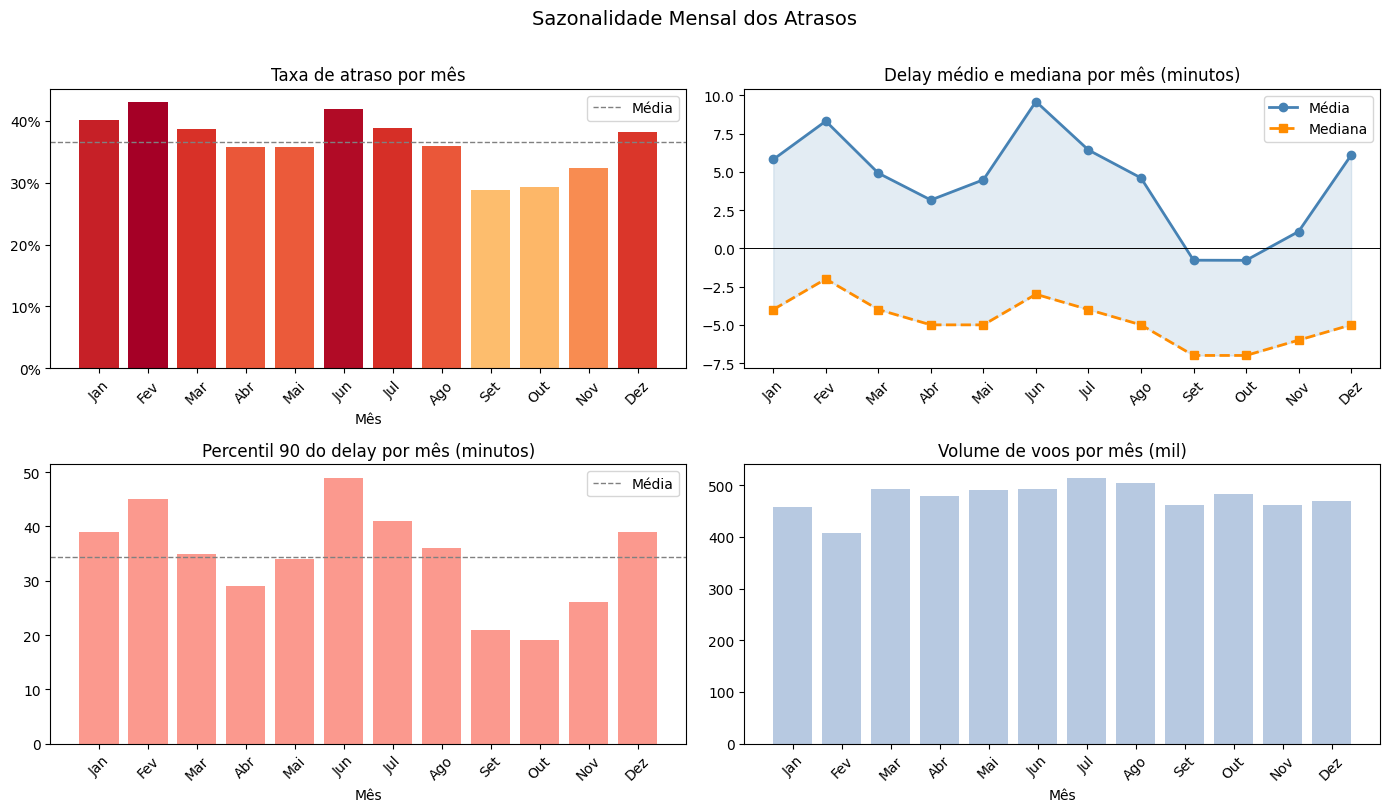

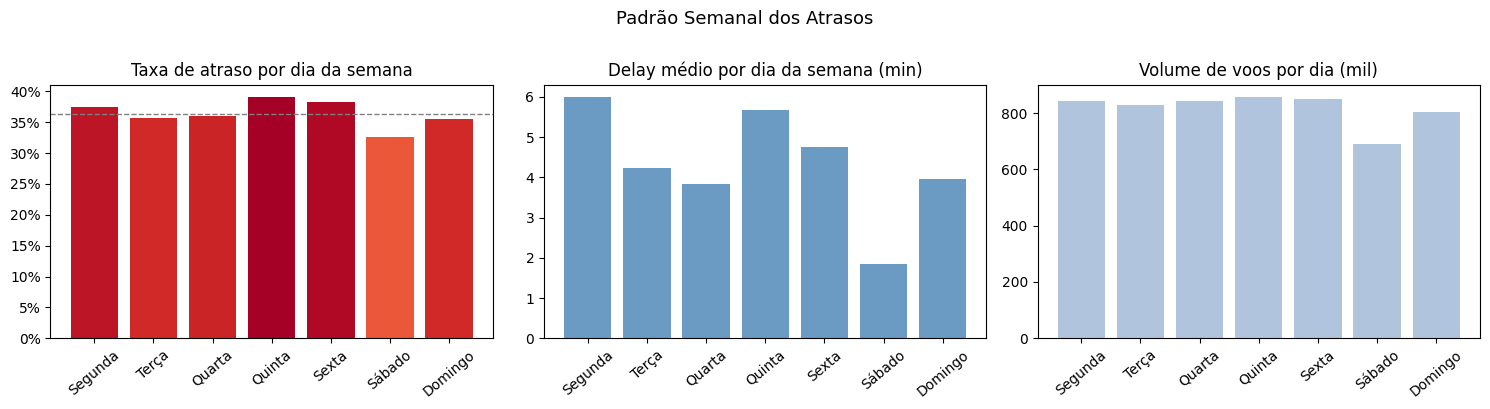

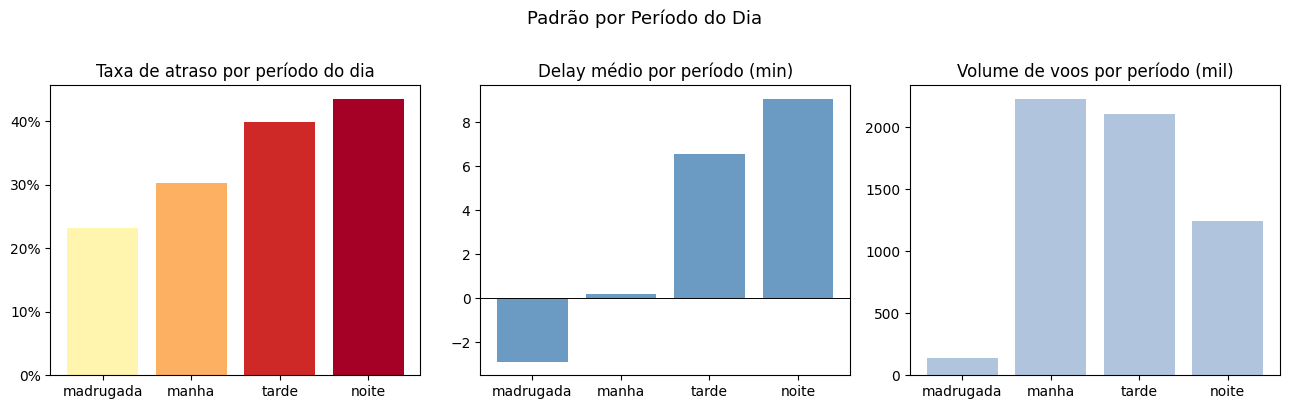

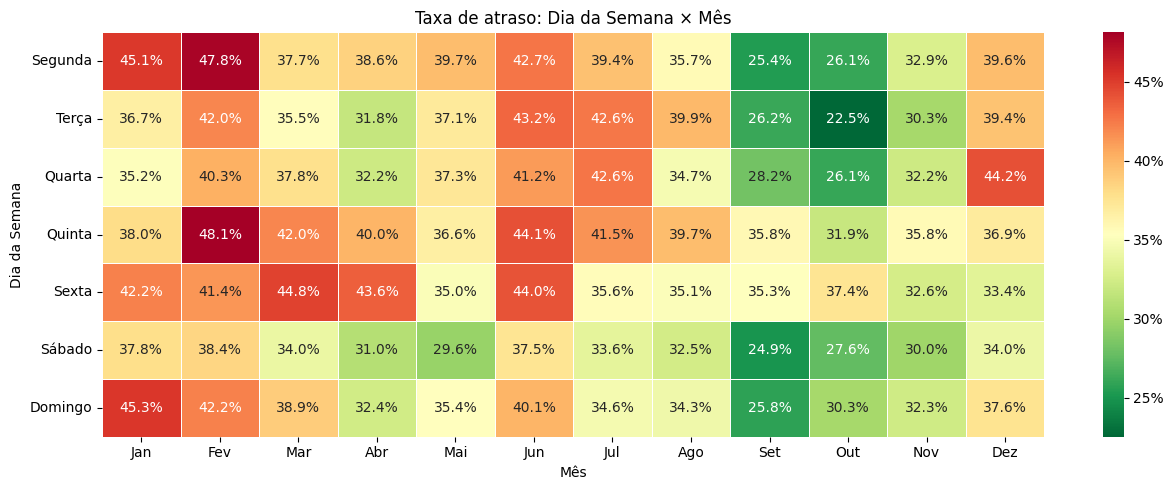

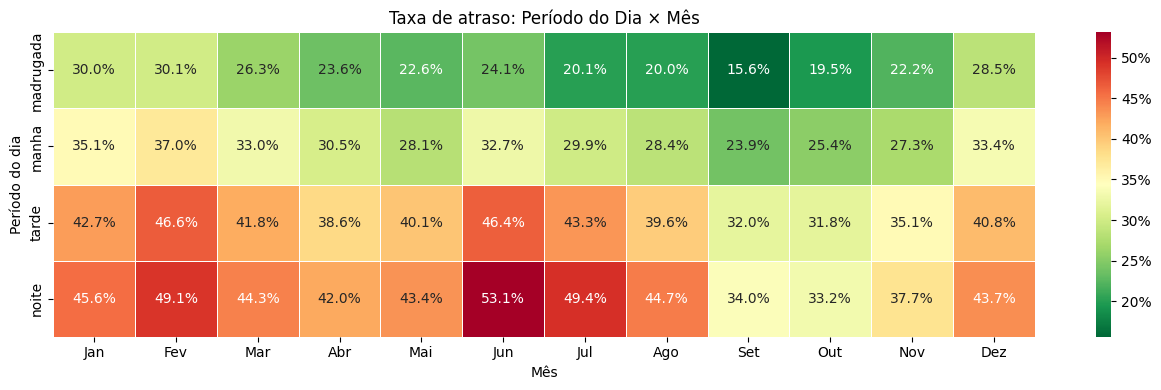

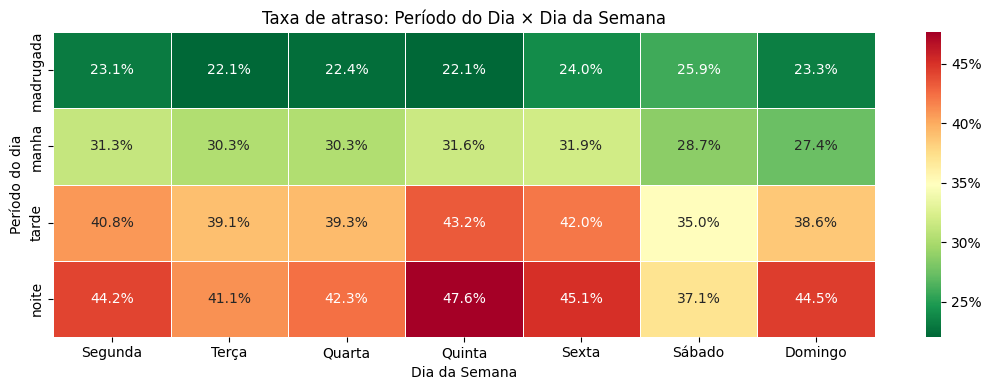

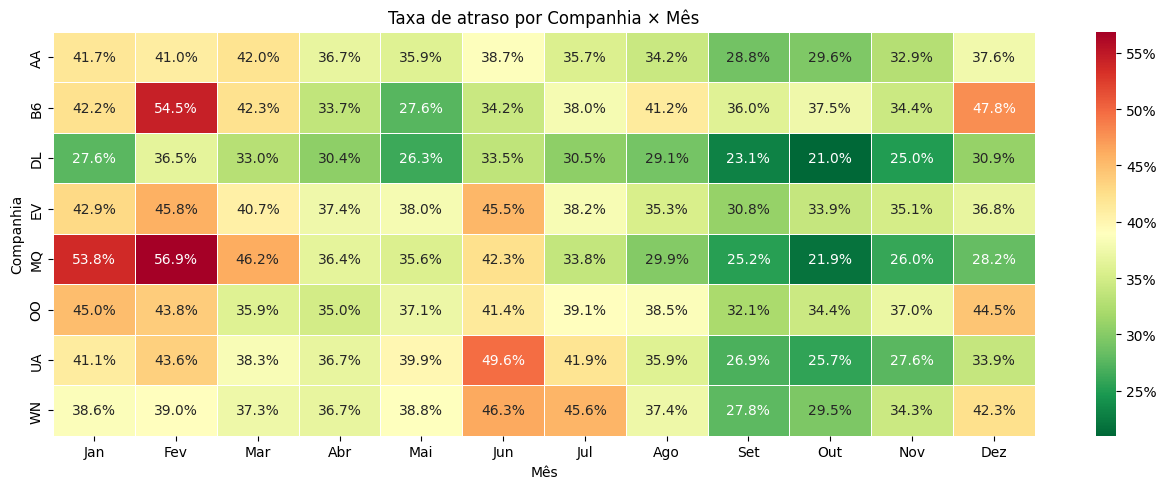

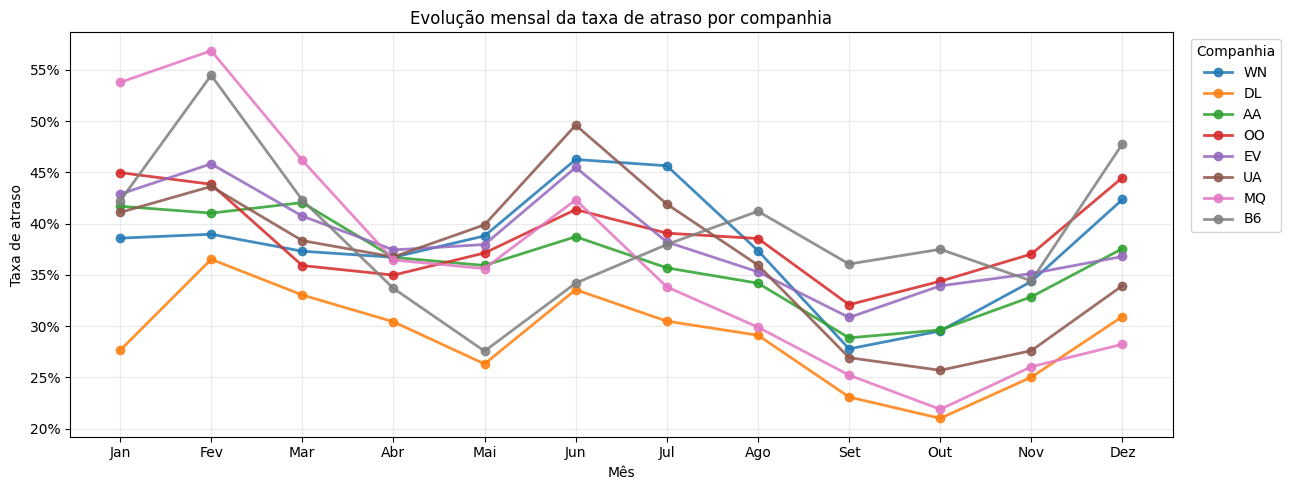

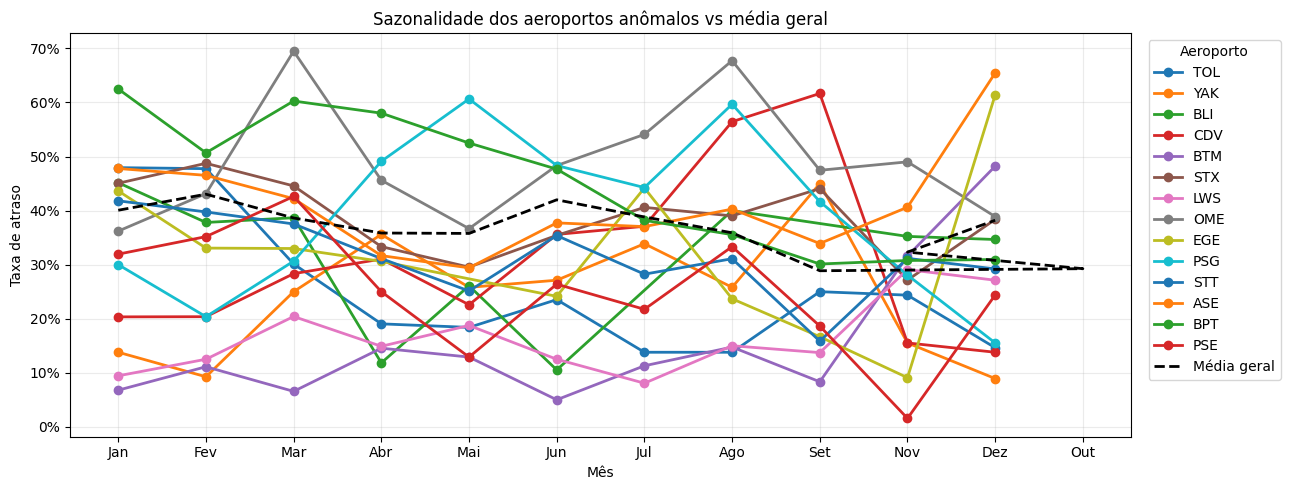

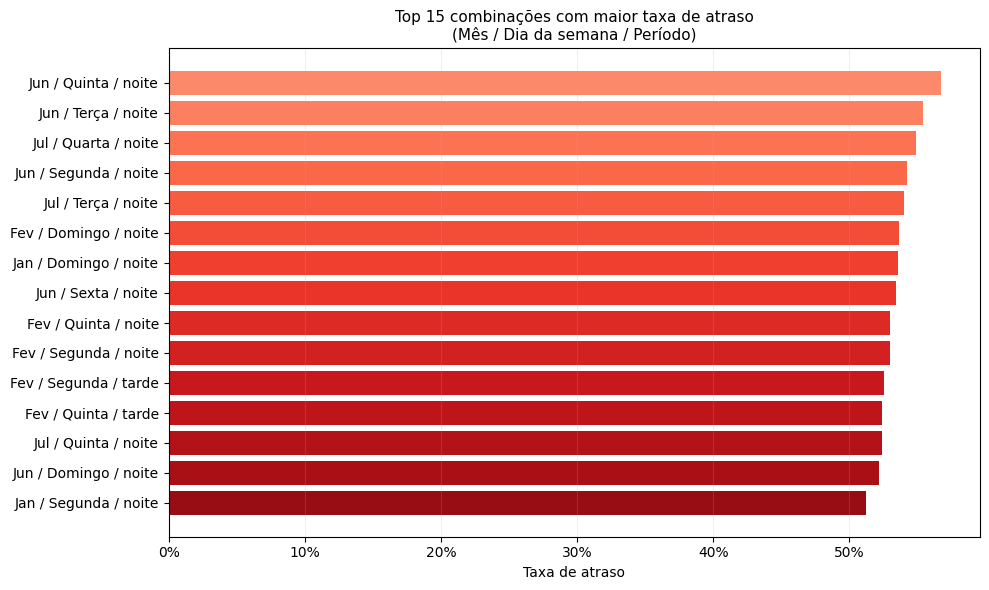


Top 5 cenários críticos:
           combinacao  taxa_atraso  media_delay  qtd_voos
 Jun / Quinta / noite     0.567462    20.981784     15920
  Jun / Terça / noite     0.553650    22.832318     18714
 Jul / Quarta / noite     0.549086    17.348197     19802
Jun / Segunda / noite     0.542044    21.023123     18683
  Jul / Terça / noite     0.540368    17.589428     15532


In [9]:
season = run_seasonality(anomalous_airports=anomalous_airports, show_plots=True)

In [10]:
# Top combinações críticas (mês + dia + período com piores taxas)
season.critical[["combinacao", "taxa_atraso", "media_delay", "qtd_voos"]].head(10)

,combinacao,taxa_atraso,media_delay,qtd_voos
0,Jun / Quinta / noite,0.567462,20.981784,15920
1,Jun / Terça / noite,0.553650,22.832318,18714
2,Jul / Quarta / noite,0.549086,17.348197,19802
3,Jun / Segunda / noite,0.542044,21.023123,18683
4,Jul / Terça / noite,0.540368,17.589428,15532
5,Fev / Domingo / noite,0.536716,16.530395,11548
6,Jan / Domingo / noite,0.535482,17.686349,13091
7,Jun / Sexta / noite,0.533954,17.174486,16007
8,Fev / Quinta / noite,0.530098,12.631185,13622
9,Fev / Segunda / noite,0.529583,15.815761,12017


In [14]:
from reports import generate_report

generate_report(
    eda=eda,
    clf=clf,
    reg=reg,
    clusterer=clusterer,
    mapper=mapper,
    detector=detector,
    season=season,
    output_path="../outputs/relatorio.html",
)

NameError: name 'clf' is not defined

## Resumo final

Todas as instâncias estão disponíveis nas variáveis `clf`, `reg`, `clusterer`, `mapper`, `detector`, `season`.  
Você pode inspecionar qualquer atributo, refazer um gráfico específico, ou comparar resultados entre etapas.

In [11]:
# Exemplo: comparar quais aeroportos anômalos estão em quais clusters
detector.anomalos_consenso[["cluster", "taxa_atraso", "taxa_atraso_grave",
                            "media_arrival_delay", "n_destinos", "qtd_voos"]].round(3)

,cluster,taxa_atraso,taxa_atraso_grave,media_arrival_delay,n_destinos,qtd_voos
ORIGIN_AIRPORT,,,,,,
TOL,3,0.245,0.153,-2.644,1,897
YAK,3,0.245,0.109,-5.632,2,650
BLI,3,0.325,0.095,-1.411,4,704
CDV,3,0.314,0.147,-1.607,2,652
BTM,3,0.153,0.065,-6.090,1,647
STX,2,0.387,0.195,4.780,4,932
LWS,3,0.165,0.039,-6.621,1,588
OME,2,0.491,0.212,7.891,2,632
EGE,2,0.388,0.234,12.402,11,1198


In [ ]:
# Roda o pipeline completo + gera o relatório HTML
main(show_plots=False, generate_html_report=True)